# Causal Impact of Fever on COVID Diagnosis

This notebook calculates the causal effect of **fever** on the probability of a **COVID diagnosis** using the **do-operator**.

The causal impact is defined as:

P(COVID | do(Fever=1)) − P(COVID | do(Fever=0))

The dataset enumerates all possible configurations of three symptoms:

• Shivering  
• Fatigue  
• Loss of Taste  

For each configuration, the spreadsheet provides:

1. Probability of COVID if fever is present  
2. Probability of COVID if fever is absent  
3. Probability of observing that configuration  

The causal probability is computed using the **backdoor adjustment formula**:

P(Y | do(X)) = Σ_z P(Y | X, Z = z) P(Z = z)

In this notebook we substitute the variables as:

Y = COVID diagnosis  
X = Fever  
Z = (Shivering, Fatigue, Loss of Taste)

So the formula becomes:

P(COVID | do(Fever)) = Σ_z P(COVID | Fever, Z = z) P(Z = z)

Where **z** represents each possible combination of the symptoms:

• Shivering  
• Fatigue  
• Loss of Taste  

Since these variables are binary (present or absent), there are **2³ = 8 possible symptom configurations**.

The spreadsheet implements this formula by computing **weighted probabilities** for each configuration and summing them to obtain:

P(COVID | do(Fever = 1))  
P(COVID | do(Fever = 0))

The difference between these two quantities gives the **causal impact of fever on COVID diagnosis**
Causal Impact = P(COVID | do(Fever=1)) − P(COVID | do(Fever=0))

In [36]:
# Import libraries used for data manipulation and DAG visualization
import pandas as pd
import matplotlib.pyplot as plt
from graphviz import Digraph
from IPython.display import display, HTML

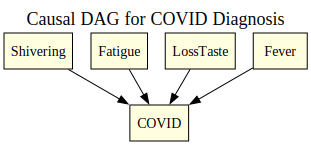

In [37]:
# The DAG describes the assumed causal relationships between variables.
# Fever directly influences COVID diagnosis.
# Other symptoms (Shivering, Fatigue, Loss of Taste) may also influence diagnosis.

g = Digraph()

g.graph_attr.update(
    label='Causal DAG for COVID Diagnosis',
    labelloc='t',
    fontsize='18'
)

g.attr('node', shape='box', style='filled', fillcolor='lightyellow')

g.node('Shivering')
g.node('Fatigue')
g.node('LossTaste')
g.node('Fever')
g.node('COVID')

g.edge('Shivering','COVID')
g.edge('Fatigue','COVID')
g.edge('LossTaste','COVID')
g.edge('Fever','COVID')

g

In [28]:
#Load spreadsheet data or create dataset

import pandas as pd

# In case you want to read the Excel file - never use spaces in a file name
#df = pd.read_excel("~/Downloads/total_effect_of_fever.xlsx")

# Show the dataframe
#print(df)

# Create the dataset instead of reading from file
data = {
    "Shivering":[1,1,1,1,0,0,0,0],
    "Fatigue":[1,1,0,0,1,1,0,0],
    "LossTaste":[1,0,1,0,1,0,1,0],
    "P_Covid_Fever":[0.63,0.63,0.62,0.61,0.62,0.61,0.60,0.59],
    "P_Covid_NoFever":[0.51,0.51,0.50,0.50,0.50,0.49,0.48,0.48],
    "Prob_Config":[0.02,0.02,0.02,0.11,0.02,0.12,0.09,0.61]
}

df = pd.DataFrame(data)

df

,Shivering,Fatigue,LossTaste,P_Covid_Fever,P_Covid_NoFever,Prob_Config
0,1,1,1,0.63,0.51,0.02
1,1,1,0,0.63,0.51,0.02
2,1,0,1,0.62,0.50,0.02
3,1,0,0,0.61,0.50,0.11
4,0,1,1,0.62,0.50,0.02
5,0,1,0,0.61,0.49,0.12
6,0,0,1,0.60,0.48,0.09
7,0,0,0,0.59,0.48,0.61


In [29]:
#Compute Weighted Probabilities
df["Weighted_Fever"] = df["P_Covid_Fever"] * df["Prob_Config"]
df["Weighted_NoFever"] = df["P_Covid_NoFever"] * df["Prob_Config"]

df

,Shivering,Fatigue,LossTaste,P_Covid_Fever,P_Covid_NoFever,Prob_Config,Weighted_Fever,Weighted_NoFever
0,1,1,1,0.63,0.51,0.02,0.0126,0.0102
1,1,1,0,0.63,0.51,0.02,0.0126,0.0102
2,1,0,1,0.62,0.50,0.02,0.0124,0.0100
3,1,0,0,0.61,0.50,0.11,0.0671,0.0550
4,0,1,1,0.62,0.50,0.02,0.0124,0.0100
5,0,1,0,0.61,0.49,0.12,0.0732,0.0588
6,0,0,1,0.60,0.48,0.09,0.0540,0.0432
7,0,0,0,0.59,0.48,0.61,0.3599,0.2928


In [30]:
#Compute Interventional Probabilities
P_do_fever = df["Weighted_Fever"].sum()
P_do_no_fever = df["Weighted_NoFever"].sum()

print("P(COVID | do(Fever=1)) =", round(P_do_fever,6))
print("P(COVID | do(Fever=0)) =", round(P_do_no_fever,6))

P(COVID | do(Fever=1)) = 0.6042
P(COVID | do(Fever=0)) = 0.4902


In [31]:
#Compute Causal Impact
causal_impact = P_do_fever - P_do_no_fever

print("Causal Impact =", round(causal_impact,6))

Causal Impact = 0.114


In [34]:
#Notebook Cell — Generate 8 Configuration DAG Panels

def make_config_graph(row, idx):

    g = Digraph()

    g.graph_attr.update(
        label=f'Configuration {idx+1}',
        labelloc='t',
        fontsize='14'
    )

    g.attr('node', shape='box', style='filled', fillcolor='lightyellow')

    g.body.append('{rank=top; Fever}')
    g.body.append('{rank=same; Shivering Fatigue LossTaste}')
    g.body.append('{rank=bottom; COVID}')

    g.node('Fever','Fever')

    g.node('Shivering',f'Shivering\n{row.Shivering}')
    g.node('Fatigue',f'Fatigue\n{row.Fatigue}')
    g.node('LossTaste',f'LossTaste\n{row.LossTaste}')

    g.node('COVID',
           f'COVID\n\n'
           f'P(COVID|Fever)={row.P_Covid_Fever}\n'
           f'P(COVID|NoFever)={row.P_Covid_NoFever}\n'
           f'Weight={row.Prob_Config}')

    g.edge('Shivering','COVID')
    g.edge('Fatigue','COVID')
    g.edge('LossTaste','COVID')
    g.edge('Fever','COVID')

    return g


graphs = []

for i,row in df.iterrows():
    graphs.append(make_config_graph(row,i))


svgs = [g.pipe(format='svg').decode('utf-8') for g in graphs]


display(HTML(f"""
<div style="display:grid; grid-template-columns: repeat(4, 1fr); gap:25px;">
{''.join(f"<div>{svg}</div>" for svg in svgs)}
</div>
"""))

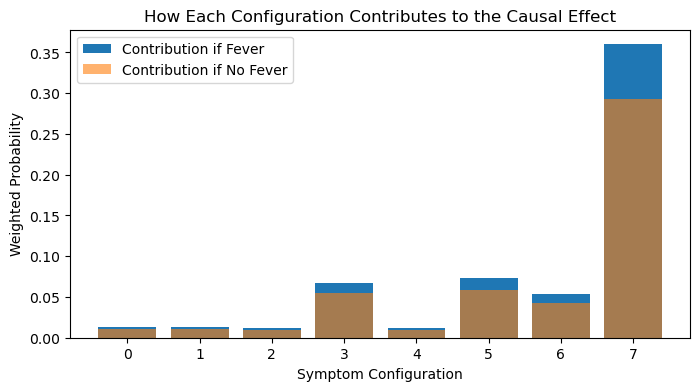

In [35]:
plt.figure(figsize=(8,4))

plt.bar(range(len(df)), df["Weighted_Fever"], label="Contribution if Fever")
plt.bar(range(len(df)), df["Weighted_NoFever"], alpha=0.6, label="Contribution if No Fever")

plt.xlabel("Symptom Configuration")
plt.ylabel("Weighted Probability")
plt.title("How Each Configuration Contributes to the Causal Effect")

plt.legend()
plt.show()

In [ ]:
# Interpretation

The causal impact of fever on COVID diagnosis is:

Causal Impact = 0.1171

This means that **setting Fever = 1 increases the probability of COVID diagnosis by approximately 11.7 percentage points**.

The calculation works by:

1. Enumerating all possible symptom configurations
2. Computing the probability of COVID under Fever=1 and Fever=0
3. Weighting each probability by the probability of that configuration
4. Summing the weighted values
5. Taking the difference between the two interventional probabilities

This procedure corresponds exactly to the **do-operator adjustment formula used in causal inference**.